# E02 · Hierarchical models: pooling, shrinkage and the funnel

| | |
|---|---|
| **Type** | Worked example - read, run, modify |
| **Data** | EPA residential radon survey: 919 homes in 85 Minnesota counties (Gelman & Hill, 2007) |
| **You will learn** | Complete vs no vs partial pooling · why shrinkage helps small groups · group indices with `coords`/`dims` · the centred parameterisation, its funnel and its divergences · the non-centred fix · group-level predictors · predicting for an unseen group · `pm.ZeroSumNormal` |

Radon is a radioactive gas that seeps into houses from the ground and is the second most
common cause of lung cancer. How much of it a house collects depends on the local geology,
so levels vary **by county** - and on where in the house you measure: basements are worse.

The practical question: *what radon level should a household in a given county expect?*
The best-surveyed county has more than a hundred measured homes, so just average them.
But a quarter of the counties have three homes or fewer. What do you tell the people who
live there?

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm

from pymc_challenges import data

RANDOM_SEED = 1987
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")

## 1 · The data

One row per house. `log_radon` is the log of the measurement in pCi/L, `floor` is 0 for a
basement measurement and 1 for the first floor, and `Uppm` is the uranium content of the
county's soil (one value per county - we will need it in section 6).

In [2]:
data.describe("radon")
radon = data.load("radon")
radon[["county", "floor", "log_radon", "Uppm"]].head()

radon: Log radon measurements in 919 Minnesota homes across 85 counties.
  source: US EPA State Residential Radon Survey (Minnesota subset), via Gelman & Hill (2007).
  url:    https://raw.githubusercontent.com/pymc-devs/pymc-examples/main/examples/data/radon.csv


,county,floor,log_radon,Uppm
0,AITKIN,1.0,0.832909,0.502054
1,AITKIN,0.0,0.832909,0.502054
2,AITKIN,0.0,1.098612,0.502054
3,AITKIN,0.0,0.095310,0.502054
4,ANOKA,0.0,1.163151,0.428565


`pd.factorize` turns county names into an integer index (`county_idx`) plus the list of
names (`counties`). The names become a **coordinate**; the integers are how each house
looks up its county's parameter. This pair is the backbone of every hierarchical model.

In [3]:
county_idx, counties = pd.factorize(radon.county, sort=True)
n_homes = radon.groupby("county").size().loc[counties]

print(f"{len(radon)} homes, {len(counties)} counties")
print(f"homes per county: median {n_homes.median():.0f}, min {n_homes.min()}, max {n_homes.max()}")
print(f"counties with 3 homes or fewer: {(n_homes <= 3).sum()}")

919 homes, 85 counties
homes per county: median 5, min 1, max 116
counties with 3 homes or fewer: 22


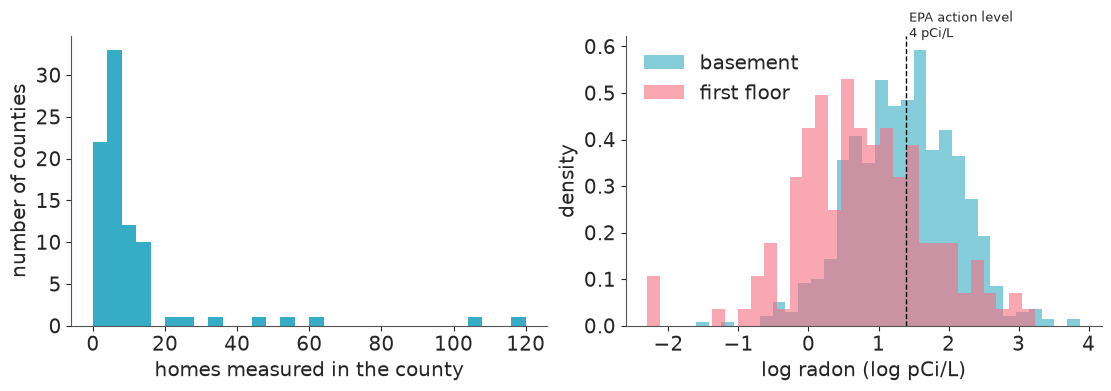

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(n_homes, bins=np.arange(0, 121, 4))
axes[0].set(xlabel="homes measured in the county", ylabel="number of counties")
for fl, label in [(0, "basement"), (1, "first floor")]:
    axes[1].hist(radon.log_radon[radon.floor == fl], bins=30, alpha=0.6, density=True, label=label)
axes[1].axvline(np.log(4), color="k", ls="--", lw=1)
axes[1].text(np.log(4) + 0.05, 0.62, "EPA action level\n4 pCi/L", fontsize=9)
axes[1].set(xlabel="log radon (log pCi/L)", ylabel="density")
axes[1].legend();

Very unbalanced groups: a couple of counties with around a hundred homes and a long list
with a handful. First-floor readings are lower than basement readings, and on the log
scale the measurements look roughly Normal.

## 2 · Two bad answers: complete pooling and no pooling

Throughout, the observation model is

$$\text{log\_radon}_i \sim \text{Normal}(\alpha_{j[i]} + \beta\,\text{floor}_i,\ \sigma)$$

where $j[i]$ is the county of house $i$. The question is what to assume about the
county intercepts $\alpha_j$.

- **Complete pooling**: $\alpha_j = \alpha$ for every county. Counties do not exist.
- **No pooling**: each $\alpha_j$ gets its own independent, wide prior. Counties have
  nothing to do with one another.

In [5]:
coords = {"county": counties}
floor = radon.floor.values
log_radon = radon.log_radon.values

with pm.Model() as pooled_model:
    alpha = pm.Normal("alpha", 1, 2)
    beta = pm.Normal("beta", 0, 1)
    sigma = pm.HalfNormal("sigma", 1)
    pm.Normal("y", alpha + beta * floor, sigma, observed=log_radon)
    pooled_idata = pm.sample(random_seed=RANDOM_SEED)

with pm.Model(coords=coords) as unpooled_model:
    alpha = pm.Normal("alpha", 1, 2, dims="county")  # 85 unrelated intercepts
    beta = pm.Normal("beta", 0, 1)
    sigma = pm.HalfNormal("sigma", 1)
    pm.Normal("y", alpha[county_idx] + beta * floor, sigma, observed=log_radon)
    unpooled_idata = pm.sample(random_seed=RANDOM_SEED)

az.summary(pooled_idata, round_to=2)

NUTS[nutpie]: [alpha, beta, sigma]


NUTS[nutpie]: [alpha, beta, sigma]


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,1.36,0.03,1.32,1.41,3853.51,3232.49,1.0,0.0,0.0
beta,-0.58,0.07,-0.70,-0.48,4062.79,3122.23,1.0,0.0,0.0
sigma,0.79,0.02,0.76,0.82,5957.28,3274.27,1.0,0.0,0.0


`alpha[county_idx]` is the whole trick: `alpha` has length 85, `county_idx` has length 919,
and fancy indexing hands every house the intercept of its own county.

Now the no-pooling estimates, ordered by how many homes back them up:

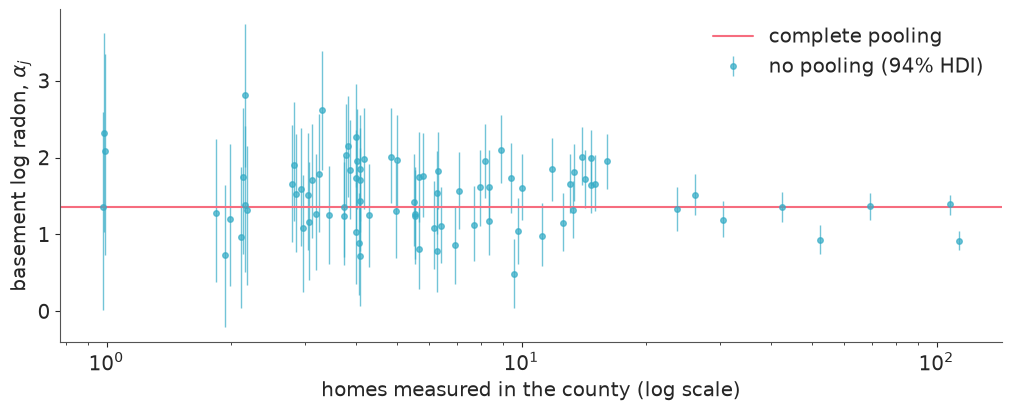

In [6]:
def county_summary(idata, var="alpha"):
    """Posterior mean and 94% HDI of a county-level variable as a DataFrame indexed by county."""
    post = idata.posterior[var]
    hdi = az.hdi(post, prob=0.94)
    return pd.DataFrame(
        {"mean": post.mean(("chain", "draw")).values, "lo": hdi.sel(ci_bound="lower").values,
         "hi": hdi.sel(ci_bound="upper").values, "n": n_homes.values},
        index=counties,
    )


unpooled = county_summary(unpooled_idata)
pooled_mean = float(pooled_idata.posterior["alpha"].mean())
jitter = np.exp(rng.normal(0, 0.06, len(counties)))  # separate counties with the same n

fig, ax = plt.subplots(figsize=(10, 4))
ax.errorbar(unpooled.n * jitter, unpooled["mean"], yerr=[unpooled["mean"] - unpooled.lo, unpooled.hi - unpooled["mean"]],
            fmt="o", ms=4, lw=1, alpha=0.7, label="no pooling (94% HDI)")
ax.axhline(pooled_mean, color="C1", label="complete pooling")
ax.set(xscale="log", xlabel="homes measured in the county (log scale)", ylabel="basement log radon, $\\alpha_j$")
ax.legend();

In [7]:
unpooled.sort_values("mean").iloc[[0, 1, -2, -1]].round(2)

,mean,lo,hi,n
LAKE,0.49,0.05,0.94,9
WASECA,0.71,0.07,1.40,4
WATONWAN,2.61,1.84,3.39,3
LAC QUI PARLE,2.81,1.88,3.73,2


Both answers are unsatisfying, in opposite ways.

- Complete pooling gives the same number to everyone, although the well-measured counties
  on the right clearly differ from one another. It **underfits**.
- No pooling takes every county at face value. The spread of the estimates fans out to
  the left: every extreme value belongs to a county with fewer than ten homes, and the two
  highest "county levels" in Minnesota are, on this reading, places where two and three
  houses were measured. That is what noise looks like. It **overfits**.

Neither model can say anything about a county with no data at all.

## 3 · Partial pooling

The hierarchical model adds one assumption: counties are different, but they are all
*counties in Minnesota* - their intercepts come from a common distribution whose mean and
spread we **learn from the data**:

$$
\begin{aligned}
\alpha_j &\sim \text{Normal}(\mu_\alpha, \sigma_\alpha) \\
\mu_\alpha &\sim \text{Normal}(1, 2), \qquad \sigma_\alpha \sim \text{HalfNormal}(1)
\end{aligned}
$$

$\sigma_\alpha$ is the dial between the two extremes above: $\sigma_\alpha \to 0$ is complete
pooling, $\sigma_\alpha \to \infty$ is no pooling. We do not set the dial; we put a prior on
it and let 85 counties tell us where it sits.

Prior scale: a typical house has 1-10 pCi/L, i.e. log radon between 0 and 2.3. A
`HalfNormal(1)` on a *log-scale* standard deviation already allows counties that differ
by a factor of $e^2 \approx 7$. Let us see what the priors imply before fitting.

In [8]:
with pm.Model(coords=coords) as varying_intercept:
    mu_alpha = pm.Normal("mu_alpha", 1, 2)
    sigma_alpha = pm.HalfNormal("sigma_alpha", 1)

    alpha = pm.Normal("alpha", mu_alpha, sigma_alpha, dims="county")
    beta = pm.Normal("beta", 0, 1)
    sigma = pm.HalfNormal("sigma", 1)

    pm.Normal("y", alpha[county_idx] + beta * floor, sigma, observed=log_radon)
    vi_idata = pm.sample_prior_predictive(500, random_seed=RANDOM_SEED)

prior_y = np.exp(vi_idata.prior_predictive["y"].values.ravel())
print("prior predictive radon (pCi/L) quantiles 5% / 50% / 95%:", np.quantile(prior_y, [0.05, 0.5, 0.95]).round(2))
print("observed radon (pCi/L)         quantiles 5% / 50% / 95%:", np.quantile(np.exp(log_radon), [0.05, 0.5, 0.95]).round(2))

Sampling: [alpha, beta, mu_alpha, sigma, sigma_alpha, y]


prior predictive radon (pCi/L) quantiles 5% / 50% / 95%: [3.0000e-02 2.9900e+00 1.6219e+02]
observed radon (pCi/L)         quantiles 5% / 50% / 95%: [ 1.    3.7  12.21]


The prior predictive distribution has its median in the right place and is about an order
of magnitude (or more) wider than the data in both directions. Weakly informative is what
we want.

In [9]:
with varying_intercept:
    vi_idata.update(pm.sample(random_seed=RANDOM_SEED))

print("divergences:", int(vi_idata.sample_stats["diverging"].sum()))
az.summary(vi_idata, var_names=["mu_alpha", "sigma_alpha", "beta", "sigma"], ci_kind="hdi", ci_prob=0.94, round_to=2)

NUTS[nutpie]: [mu_alpha, sigma_alpha, alpha, beta, sigma]


divergences: 0


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_alpha,1.49,0.05,1.39,1.58,1560.20,1938.20,1.0,0.0,0.0
sigma_alpha,0.32,0.04,0.24,0.41,976.05,1327.46,1.0,0.0,0.0
beta,-0.66,0.07,-0.79,-0.54,2657.98,2739.92,1.0,0.0,0.0
sigma,0.73,0.02,0.69,0.76,4587.55,2659.29,1.0,0.0,0.0


Clean diagnostics. The numbers to read are the two standard deviations: homes *within* a
county differ by $\sigma \approx 0.73$, county means differ by only
$\sigma_\alpha \approx 0.32$. Most of the variation in radon is between houses, not between
counties - so a county average based on two houses is mostly house-to-house noise, and
the model knows that.

### Shrinkage

Here are the same counties as before, now with both estimates. Arrows go from the
no-pooling estimate to the partial-pooling one.

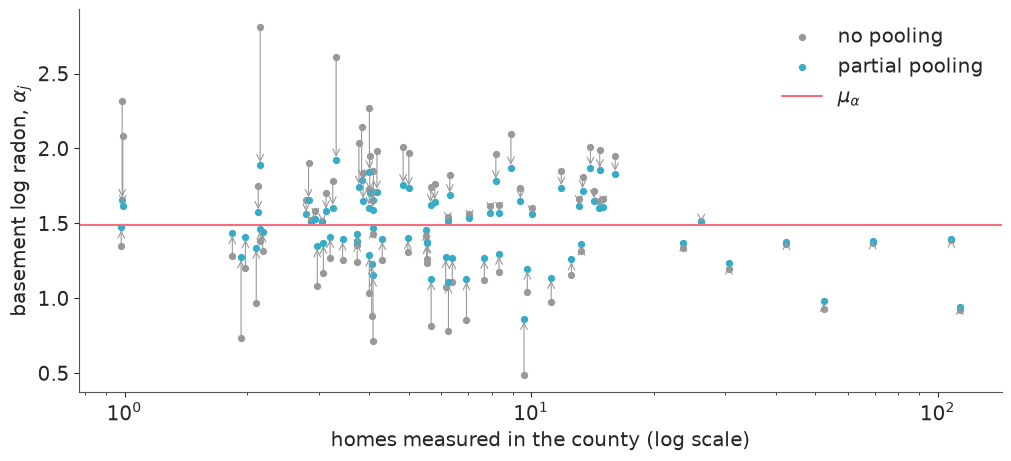

In [10]:
partial = county_summary(vi_idata)
mu_alpha_mean = float(vi_idata.posterior["mu_alpha"].mean())

fig, ax = plt.subplots(figsize=(10, 4.5))
x = unpooled.n * jitter
ax.scatter(x, unpooled["mean"], s=18, color="0.6", label="no pooling")
ax.scatter(x, partial["mean"], s=18, color="C0", label="partial pooling")
for xi, y0, y1 in zip(x, unpooled["mean"], partial["mean"]):
    ax.annotate("", xy=(xi, y1), xytext=(xi, y0), arrowprops=dict(arrowstyle="->", color="0.6", lw=0.8))
ax.axhline(mu_alpha_mean, color="C1", label="$\\mu_\\alpha$")
ax.set(xscale="log", xlabel="homes measured in the county (log scale)", ylabel="basement log radon, $\\alpha_j$")
ax.legend();

In [11]:
shrink = pd.DataFrame({
    "n": n_homes.values,
    "moved": (partial["mean"] - unpooled["mean"]).abs(),
    "hdi_width_no_pooling": unpooled.hi - unpooled.lo,
    "hdi_width_partial": partial.hi - partial.lo,
})
shrink.groupby(pd.cut(shrink.n, [0, 3, 10, 30, 120])).mean().drop(columns="n").round(2)

,moved,hdi_width_no_pooling,hdi_width_partial
n,,,
"(0, 3]",0.27,1.79,1.01
"(3, 10]",0.18,1.15,0.84
"(10, 30]",0.08,0.73,0.63
"(30, 120]",0.02,0.35,0.34


Every estimate moves towards the population mean, and **how far depends on how much data
the county has**. Counties with 1-3 homes move the most and their intervals are almost
halved; the large counties on the right hardly move and keep their (already narrow)
intervals. Note in passing that $\mu_\alpha$ sits above the complete-pooling line of
section 2: the biggest counties happen to have low radon, and complete pooling lets their
many houses dominate, whereas $\mu_\alpha$ is the mean *over counties*.
Nobody coded that rule - it is what Bayes' theorem does when a county's own likelihood
(weak or strong) meets the population distribution (the prior that the other 84
counties estimated).

For a county with $n_j$ homes the posterior mean is approximately a precision-weighted
average

$$\hat\alpha_j \approx \frac{(n_j/\sigma^2)\,\bar y_j + (1/\sigma_\alpha^2)\,\mu_\alpha}{n_j/\sigma^2 + 1/\sigma_\alpha^2}$$

With our estimates, $\sigma^2/\sigma_\alpha^2 \approx 5$: the population prior is worth
about five houses. A county with one house keeps roughly 1/6 of its own signal; a county
with 100 keeps 95%.

### Does shrinkage actually predict better?

It is a fair question - we have biased every estimate on purpose. PSIS-LOO estimates
out-of-sample predictive accuracy for each of the three models.

In [12]:
for model, idata in [(pooled_model, pooled_idata), (unpooled_model, unpooled_idata), (varying_intercept, vi_idata)]:
    with model:
        pm.compute_log_likelihood(idata, progressbar=False)

az.compare({"complete pooling": pooled_idata, "no pooling": unpooled_idata, "partial pooling": vi_idata})

/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
partial pooling,0,0.0,0.0,NaN,,,49.4,-1040.0,28.0,0.92
no pooling,1,-20.0,6.0,1.0,,4 k̂ > 0.70,84.2,-1060.0,29.0,0.00
complete pooling,2,-50.0,11.0,1.0,,,3.7,-1090.0,25.0,0.08


Partial pooling predicts held-out houses best, by a margin of about three standard errors
over no pooling and more over complete pooling (`elpd_diff` against `dse`). Look at column
`p`, the effective number of parameters: the
no-pooling model spends about 85; the hierarchical model has *more* parameters on paper
(two hyperparameters on top) but only about 50 effective ones, because shrinkage
restrains them. (No pooling also triggers Pareto-$k$ warnings: in a
county with a single house, leaving that house out changes the county's posterior
completely, which is exactly what importance sampling cannot handle. Its `elpd` is
therefore approximate - but the ranking is not in doubt.)

## 4 · When the sampler complains: varying slopes and the funnel

So far NUTS had an easy time. Let us make the model a little more ambitious: maybe the
basement/first-floor difference is not the same everywhere (housing stock differs), so
give every county its own slope as well:

$$\beta_j \sim \text{Normal}(\mu_\beta, \sigma_\beta)$$

Written exactly like the intercepts - the **centred** parameterisation.

A note on samplers: in this environment `pm.sample()` uses **nutpie** by default. For this
one section we fit with both nutpie and PyMC's own NUTS implementation
(`nuts_sampler="pymc"`), because they fail in instructively different ways.

In [13]:
with pm.Model(coords=coords) as centred:
    mu_alpha = pm.Normal("mu_alpha", 1, 2)
    sigma_alpha = pm.HalfNormal("sigma_alpha", 1)
    mu_beta = pm.Normal("mu_beta", 0, 1)
    sigma_beta = pm.HalfNormal("sigma_beta", 1)

    alpha = pm.Normal("alpha", mu_alpha, sigma_alpha, dims="county")
    beta = pm.Normal("beta", mu_beta, sigma_beta, dims="county")  # centred: beta_j drawn directly
    sigma = pm.HalfNormal("sigma", 1)

    pm.Normal("y", alpha[county_idx] + beta[county_idx] * floor, sigma, observed=log_radon)

    centred_nutpie = pm.sample(random_seed=RANDOM_SEED)
    centred_idata = pm.sample(nuts_sampler="pymc", random_seed=RANDOM_SEED)

NUTS[nutpie]: [mu_alpha, sigma_alpha, mu_beta, sigma_beta, alpha, beta, sigma]


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu_alpha, sigma_alpha, mu_beta, sigma_beta, alpha, beta, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


There were 104 divergences after tuning. Increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [14]:
def sampler_report(fits, var="sigma_beta"):
    rows = {}
    for name, idata in fits.items():
        s = az.summary(idata, var_names=[var], round_to=3)
        rows[name] = {
            "divergences": int(idata.sample_stats["diverging"].sum()),
            f"{var} mean": s["mean"].iloc[0], "ess_bulk": s["ess_bulk"].iloc[0], "r_hat": s["r_hat"].iloc[0],
            f"smallest {var} visited": float(idata.posterior[var].min()),
            f"P({var} < 0.05)": float((idata.posterior[var] < 0.05).mean()),
        }
    return pd.DataFrame(rows).T


sampler_report({"centred, nutpie": centred_nutpie, "centred, PyMC NUTS": centred_idata})

,divergences,sigma_beta mean,ess_bulk,r_hat,smallest sigma_beta visited,P(sigma_beta < 0.05)
"centred, nutpie",7.0,0.242,36.517,1.083,0.055712,0.0
"centred, PyMC NUTS",104.0,0.269,34.610,1.130,0.059106,0.0


Something is wrong. Both samplers agree on the symptoms that matter: for $\sigma_\beta$,
out of 4000 draws only a few dozen are effectively independent (`ess_bulk`) and the chains
do not agree with each other (`r_hat` far above 1.01). PyMC's NUTS also reports about a
hundred **divergences**; nutpie, which adapts its step size and mass matrix differently,
only a handful. The divergence count is erratic: rerunning this cell with six other seeds
we saw between 41 and 207 with PyMC's NUTS and between 0 and 17 with nutpie - including
nutpie runs with **zero** divergences whose ESS was still around 60 and whose `r_hat` was
still 1.05. **A low divergence count is not a clean bill of health**; always read ESS and
`r_hat` too.

A divergence means the numerical trajectory flew off the true one because the posterior's
curvature changed faster than the step size could follow. *Where* they happen tells you
which part of the posterior is the problem. `az.plot_pair` can mark them:

25 counties have no first-floor measurement; using ITASCA (n = 11)


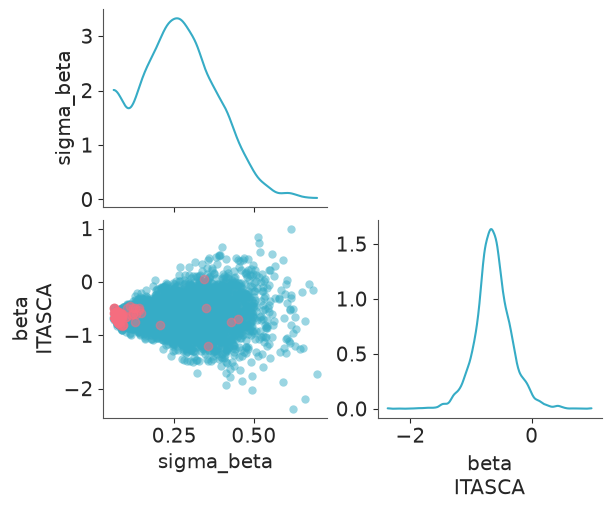

In [15]:
# a county with no first-floor measurement at all: its slope is informed only by the population
no_first_floor = radon.groupby("county").floor.sum().loc[lambda s: s == 0].index
funnel_county = n_homes.loc[no_first_floor].idxmax()
print(f"{len(no_first_floor)} counties have no first-floor measurement; using {funnel_county} (n = {n_homes[funnel_county]})")

az.plot_pair(
    centred_idata, var_names=["sigma_beta", "beta"], coords={"county": [funnel_county]},
    visuals={"divergence": True}, figure_kwargs={"figsize": (6, 5)},
);

The divergences sit at **small $\sigma_\beta$**. To see why, put $\sigma_\beta$ on a log
scale - this is the space the sampler actually works in.

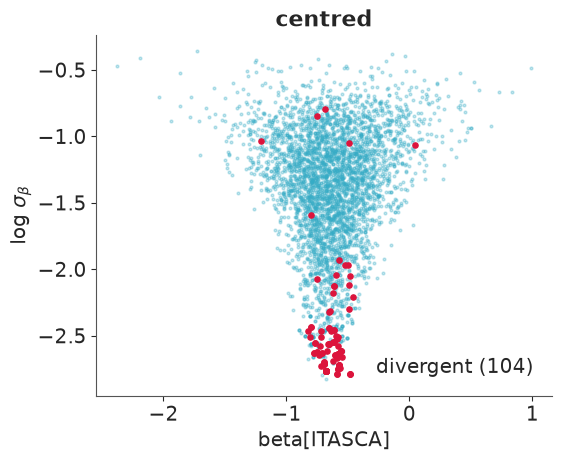

In [16]:
def funnel_plot(idata, ax, title, y_var="beta"):
    post = az.extract(idata, var_names=["sigma_beta", y_var], keep_dataset=True)
    div = idata.sample_stats["diverging"].stack(sample=("chain", "draw")).values
    yv = post[y_var].sel(county=funnel_county).values
    log_s = np.log(post["sigma_beta"].values)
    ax.scatter(yv[~div], log_s[~div], s=4, alpha=0.3, color="C0")
    ax.scatter(yv[div], log_s[div], s=14, color="crimson", label=f"divergent ({div.sum()})")
    ax.set(title=title, xlabel=f"{y_var}[{funnel_county}]")
    ax.legend(loc="lower right")


fig, ax = plt.subplots(figsize=(5.5, 4.5))
funnel_plot(centred_idata, ax, "centred")
ax.set(ylabel="log $\\sigma_\\beta$");

**Neal's funnel.** When $\sigma_\beta$ is large, $\beta_j$ is free to roam; when
$\sigma_\beta$ is small, all 85 $\beta_j$ are squeezed into a tiny interval around
$\mu_\beta$. The posterior is wide at the top and needle-thin at the bottom. A step size
tuned for the mouth of the funnel overshoots in the neck (divergence), and one tuned for
the neck would take forever to cross the mouth. The sampler gives up on the neck: neither
run ever visits $\sigma_\beta < 0.05$ (last columns of the table), although nothing in the
model or the data rules such values out. Whatever posterior mass lives down there is simply
missing from our draws. That is the real damage: not the warning, a potentially wrong answer.

Why did the intercepts not do this? Because $\sigma_\alpha$ is pinned well away from zero
by the data (0.32 ± 0.05), so the sampler never needs to visit the neck. The slopes are a
different story: only 153 of 919 measurements are on a first floor and 25 counties have
none at all, so $\sigma_\beta$ is poorly identified and **zero is plausible**. Funnels bite
when group-level standard deviations are weakly informed - few groups, little data per
group, or a true value near zero.

### The fix: non-centred parameterisation

Do not tune the sampler (raising `target_accept` only shrinks the step size and makes the
neck *slightly* more reachable at a big cost). Change the geometry instead. Sample a
standardised offset and build $\beta_j$ from it:

$$z_j \sim \text{Normal}(0, 1), \qquad \beta_j = \mu_\beta + \sigma_\beta\, z_j$$

The model is *identical* - same prior on $\beta_j$, same likelihood - but the sampler now
moves in $(z_j, \sigma_\beta)$, which are independent a priori. No funnel.

In [17]:
with pm.Model(coords=coords) as noncentred:
    mu_alpha = pm.Normal("mu_alpha", 1, 2)
    sigma_alpha = pm.HalfNormal("sigma_alpha", 1)
    mu_beta = pm.Normal("mu_beta", 0, 1)
    sigma_beta = pm.HalfNormal("sigma_beta", 1)

    z_alpha = pm.Normal("z_alpha", 0, 1, dims="county")
    z_beta = pm.Normal("z_beta", 0, 1, dims="county")
    alpha = pm.Deterministic("alpha", mu_alpha + sigma_alpha * z_alpha, dims="county")
    beta = pm.Deterministic("beta", mu_beta + sigma_beta * z_beta, dims="county")
    sigma = pm.HalfNormal("sigma", 1)

    pm.Normal("y", alpha[county_idx] + beta[county_idx] * floor, sigma, observed=log_radon)
    noncentred_idata = pm.sample(random_seed=RANDOM_SEED)  # default sampler (nutpie)

sampler_report({"centred, nutpie": centred_nutpie, "centred, PyMC NUTS": centred_idata,
                "non-centred, nutpie": noncentred_idata})

NUTS[nutpie]: [mu_alpha, sigma_alpha, mu_beta, sigma_beta, z_alpha, z_beta, sigma]


,divergences,sigma_beta mean,ess_bulk,r_hat,smallest sigma_beta visited,P(sigma_beta < 0.05)
"centred, nutpie",7.0,0.242,36.517,1.083,0.055712,0.000
"centred, PyMC NUTS",104.0,0.269,34.610,1.130,0.059106,0.000
"non-centred, nutpie",0.0,0.262,708.992,1.005,0.000332,0.052


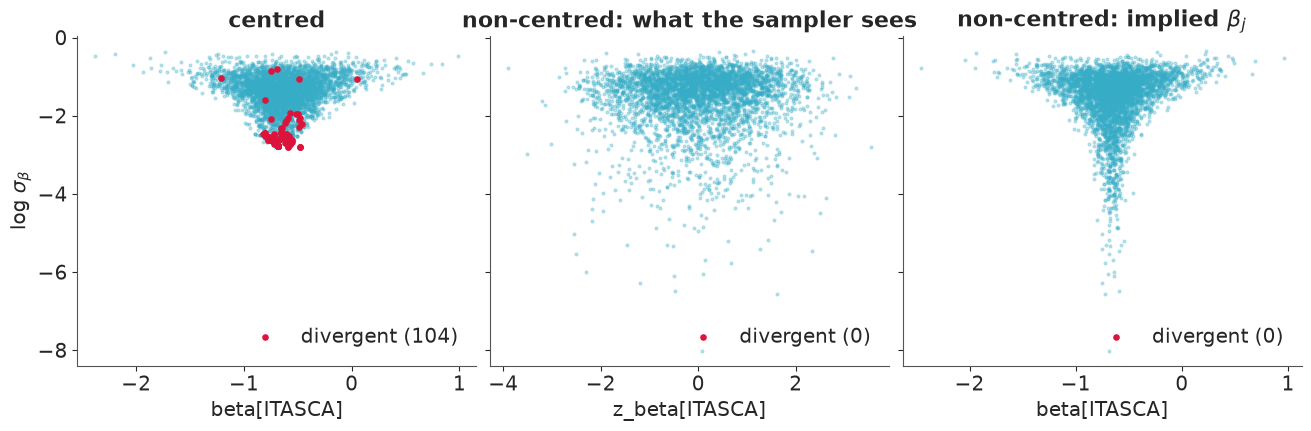

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
funnel_plot(centred_idata, axes[0], "centred")
funnel_plot(noncentred_idata, axes[1], "non-centred: what the sampler sees", y_var="z_beta")
funnel_plot(noncentred_idata, axes[2], "non-centred: implied $\\beta_j$")
axes[0].set(ylabel="log $\\sigma_\\beta$");

Same model, same data, same seed - only the parameterisation changed. The middle panel
is what NUTS explores now: a shapeless blob, easy. The right panel maps those draws back
to $\beta_j$: the funnel is still there (it is a property of the *model*), but now its neck
is populated, reaching $\sigma_\beta$ two orders of magnitude smaller than the centred runs
ever visited. The table says how much the centred fits were missing: the region
$\sigma_\beta < 0.05$, to which they gave probability zero, holds about 5% of the
posterior. ESS is up twenty-fold and `r_hat` is fine.

Be careful what you conclude from the posterior *means* in that table. The two centred
runs disagree with each other (0.24 and 0.27) about as much as with the non-centred one
(0.26): with an ESS of 35 their Monte Carlo error swamps the bias from the missing neck.
This time the centred answers were not far off. You could not have known that from the
centred fits alone - and that is the point of diagnostics.

**Rule of thumb.** Non-centred is the safe default for hierarchical models. It is not
free of trouble, though: it has the mirror-image problem when groups are *strongly*
informed by their own data, because then the likelihood ties $z_j$ and $\sigma$ together
instead. Centred is the better choice when every group has lots of data and the
group-level sd is clearly non-zero. You can mix: centred for one set of effects,
non-centred for another (exercise 2 below looks at this).

And the substantive answer? $\sigma_\beta$ is small and consistent with zero, so there is no
strong evidence that the floor effect varies by county:

In [19]:
az.summary(noncentred_idata, var_names=["mu_alpha", "sigma_alpha", "mu_beta", "sigma_beta", "sigma"],
           ci_kind="hdi", ci_prob=0.94, round_to=2)

,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_alpha,1.49,0.05,1.39,1.59,1881.43,2156.36,1.00,0.0,0.0
sigma_alpha,0.32,0.05,0.24,0.41,1554.36,1985.80,1.00,0.0,0.0
mu_beta,-0.65,0.08,-0.79,-0.49,3730.49,3056.61,1.00,0.0,0.0
sigma_beta,0.26,0.13,0.02,0.47,708.99,988.66,1.01,0.0,0.0
sigma,0.72,0.02,0.69,0.75,4632.53,3232.13,1.00,0.0,0.0


## 5 · Aside: `pm.ZeroSumNormal`

There is a second, subtler geometry problem in every varying-intercept model: you can add a
constant to $\mu_\alpha$ and subtract it from all the offsets and the likelihood does not
change - only the prior holds them in place. With many groups that is harmless; with few
groups, or several crossed factors (team attack + team defence + home advantage...), it
becomes a real identifiability problem.

`pm.ZeroSumNormal` is the modern tool: a Normal whose values are constrained to **sum to
zero** along a dimension. The intercept is then unambiguously "the average county", and
the offsets are deviations from it.

In [20]:
with pm.Model(coords=coords) as zerosum_model:
    mu_alpha = pm.Normal("mu_alpha", 1, 2)
    sigma_alpha = pm.HalfNormal("sigma_alpha", 1)
    offset = pm.ZeroSumNormal("offset", sigma=sigma_alpha, dims="county")
    alpha = pm.Deterministic("alpha", mu_alpha + offset, dims="county")
    beta = pm.Normal("beta", 0, 1)
    sigma = pm.HalfNormal("sigma", 1)
    pm.Normal("y", alpha[county_idx] + beta * floor, sigma, observed=log_radon)
    zerosum_idata = pm.sample(random_seed=RANDOM_SEED)

pd.concat({
    "Normal(mu, sigma)": az.summary(vi_idata, var_names=["mu_alpha", "sigma_alpha"], round_to=3),
    "mu + ZeroSumNormal": az.summary(zerosum_idata, var_names=["mu_alpha", "sigma_alpha"], round_to=3),
})[["mean", "sd", "ess_bulk", "r_hat"]]

NUTS[nutpie]: [mu_alpha, sigma_alpha, offset, beta, sigma]


mean     sd  ess_bulk  r_hat
Normal(mu, sigma)  mu_alpha     1.490  0.050  1560.201  1.002
                   sigma_alpha  0.319  0.045   976.046  1.001
mu + ZeroSumNormal mu_alpha     1.492  0.036  1739.040  1.001
                   sigma_alpha  0.319  0.046   721.731  1.005

In [21]:
zs = county_summary(zerosum_idata)
print("largest difference in county intercepts between the two models:",
      float((zs["mean"] - partial["mean"]).abs().max().round(3)))

largest difference in county intercepts between the two models: 0.01


The county estimates are the same to within Monte Carlo error, $\sigma_\alpha$ is the same,
but $\mu_\alpha$ has a smaller posterior sd. That is not a free lunch, it is a different
*question*: with `ZeroSumNormal`, $\mu_\alpha$ is the mean of **these 85 counties**; in the
standard model it is the mean of the *population counties are drawn from*, which is less
certain. Use the standard form when you want to generalise to new groups (section 7);
use `ZeroSumNormal` when the groups are the whole population of interest and you want
identifiable, well-behaved offsets. Challenge **C02** needs it.

## 6 · A group-level predictor: uranium

Shrinking towards the state average is sensible when you know nothing else about a county.
But we do: radon comes from uranium in the soil, and we have a soil measurement per county.
Let the *population mean itself* depend on it:

$$\alpha_j \sim \text{Normal}(\gamma_0 + \gamma_1\, \log u_j,\ \sigma_\alpha)$$

Small counties are now shrunk towards **the regression line** - towards counties with
similar geology - rather than towards one grand mean. We go back to a common floor effect
(section 4 found no evidence for varying slopes), use the non-centred form, and register
inputs with `pm.Data`. Note the two different dims: `log_u` lives on `county`, the
observations on `obs`.

In [22]:
log_u = np.log(radon.groupby("county").Uppm.first().loc[counties].values)
coords = {"county": counties, "obs": radon.index}

with pm.Model(coords=coords) as uranium_model:
    county_id = pm.Data("county_id", county_idx, dims="obs")
    floor_d = pm.Data("floor", floor, dims="obs")
    log_u_d = pm.Data("log_u", log_u, dims="county")

    gamma_0 = pm.Normal("gamma_0", 1, 2)
    gamma_1 = pm.Normal("gamma_1", 0, 1)
    sigma_alpha = pm.HalfNormal("sigma_alpha", 1)
    z = pm.Normal("z", 0, 1, dims="county")
    alpha = pm.Deterministic("alpha", gamma_0 + gamma_1 * log_u_d + sigma_alpha * z, dims="county")

    beta = pm.Normal("beta", 0, 1)
    sigma = pm.HalfNormal("sigma", 1)

    pm.Normal("y", alpha[county_id] + beta * floor_d, sigma, observed=log_radon, dims="obs")
    uranium_idata = pm.sample(random_seed=RANDOM_SEED)

print("divergences:", int(uranium_idata.sample_stats["diverging"].sum()))
az.summary(uranium_idata, var_names=["gamma_0", "gamma_1", "sigma_alpha", "beta", "sigma"],
           ci_kind="hdi", ci_prob=0.94, round_to=2)

NUTS[nutpie]: [gamma_0, gamma_1, sigma_alpha, z, beta, sigma]


divergences: 0


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
gamma_0,1.49,0.04,1.43,1.57,1620.41,1924.47,1.0,0.0,0.0
gamma_1,0.69,0.09,0.53,0.86,2039.49,2391.06,1.0,0.0,0.0
sigma_alpha,0.15,0.05,0.06,0.24,733.67,953.59,1.0,0.0,0.0
beta,-0.63,0.07,-0.76,-0.51,3002.27,2332.17,1.0,0.0,0.0
sigma,0.73,0.02,0.70,0.76,3376.27,2779.08,1.0,0.0,0.0


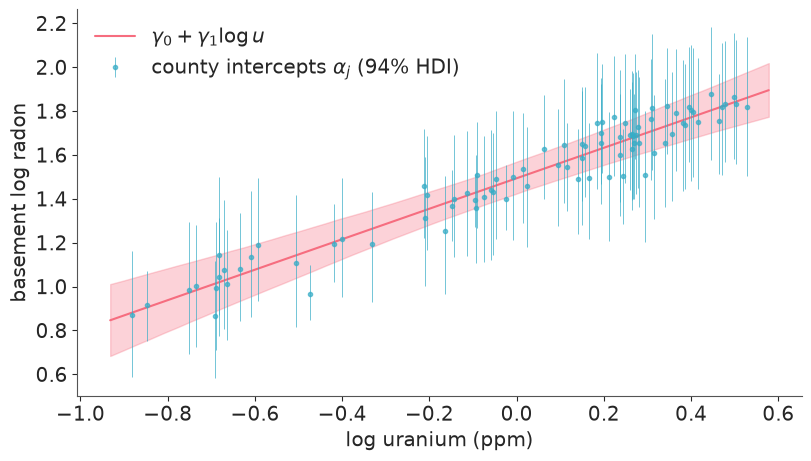

In [23]:
post = az.extract(uranium_idata, var_names=["gamma_0", "gamma_1"])
u_grid = np.linspace(log_u.min() - 0.05, log_u.max() + 0.05, 50)
lines = post["gamma_0"].values[:, None] + post["gamma_1"].values[:, None] * u_grid
with_u = county_summary(uranium_idata)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.fill_between(u_grid, *np.quantile(lines, [0.03, 0.97], axis=0), color="C1", alpha=0.3)
ax.plot(u_grid, lines.mean(axis=0), color="C1", label="$\\gamma_0 + \\gamma_1 \\log u$")
ax.errorbar(log_u, with_u["mean"], yerr=[with_u["mean"] - with_u.lo, with_u.hi - with_u["mean"]],
            fmt="o", ms=3, lw=0.7, alpha=0.7, label="county intercepts $\\alpha_j$ (94% HDI)")
ax.set(xlabel="log uranium (ppm)", ylabel="basement log radon")
ax.legend();

Uranium explains a large part of the between-county differences: $\gamma_1$ is clearly
positive, and $\sigma_\alpha$ - the county variation left *unexplained* - has roughly halved
compared with section 3. The remaining county effects hug the line. A good group-level
predictor makes partial pooling stronger, because the thing being pooled towards is
better.

### Posterior predictive check

Does the model reproduce the data? First the overall distribution, then a statistic that
matters for the application and that the model never saw directly: the share of homes
above the EPA action level of 4 pCi/L.

Sampling: [y]


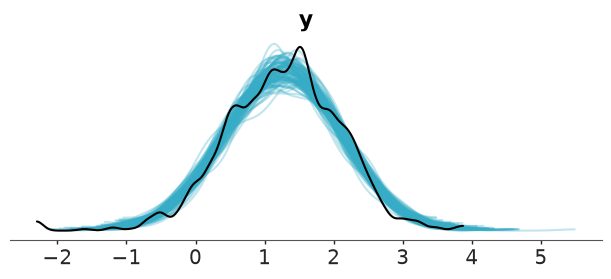

In [24]:
with uranium_model:
    pm.sample_posterior_predictive(uranium_idata, extend_inferencedata=True, random_seed=RANDOM_SEED)

az.plot_ppc_dist(uranium_idata, num_samples=100);

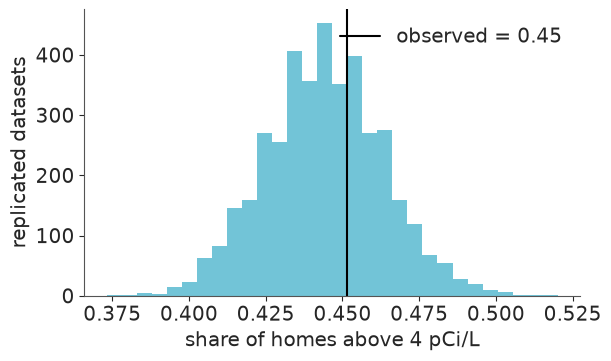

In [25]:
y_rep = az.extract(uranium_idata, group="posterior_predictive", var_names="y").values  # (obs, sample)
share_rep = (y_rep > np.log(4)).mean(axis=0)
share_obs = (log_radon > np.log(4)).mean()

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(share_rep, bins=30, alpha=0.7)
ax.axvline(share_obs, color="k", label=f"observed = {share_obs:.2f}")
ax.set(xlabel="share of homes above 4 pCi/L", ylabel="replicated datasets")
ax.legend();

The replicated datasets look like the real one (the small bump at the far left of the
observed curve is three readings at 0.1 pCi/L, the lowest value recorded), and the
observed share of homes above the action level is a typical value under the model.

## 7 · Predicting for a county we have never seen

This is where hierarchical models earn their keep. Suppose a new county is surveyed for
soil uranium (say 1.2 ppm) but **not a single house** has been measured. No pooling has
nothing to say. The hierarchical model says: its intercept is one more draw from the
population distribution.

The cleanest way to do this in PyMC is to **extend the fitted model** with new random
variables that reuse the posterior of the hyperparameters, then ask
`sample_posterior_predictive` for just those variables. They were not in the posterior, so
PyMC forward-samples them, once per posterior draw.

In [26]:
NEW_U = 1.2  # ppm

with uranium_model:
    alpha_new = pm.Normal("alpha_new", gamma_0 + gamma_1 * np.log(NEW_U), sigma_alpha)
    # a new house in the new county: basement, first floor
    pm.Normal("y_new", alpha_new + beta * np.array([0.0, 1.0]), sigma, shape=2)
    new_pred = pm.sample_posterior_predictive(
        uranium_idata, var_names=["alpha_new", "y_new"], predictions=True, random_seed=RANDOM_SEED
    )

y_new = new_pred.predictions["y_new"]
for i, where in enumerate(["basement", "first floor"]):
    draws = np.exp(y_new.isel(y_new_dim_0=i).values.ravel())
    lo, hi = np.quantile(draws, [0.03, 0.97])
    print(f"new county, {where:<11}: median {np.median(draws):.1f} pCi/L, 94% interval [{lo:.1f}, {hi:.1f}], "
          f"P(> 4 pCi/L) = {(draws > 4).mean():.2f}")

Sampling: [alpha_new, y_new]


new county, basement   : median 5.1 pCi/L, 94% interval [1.2, 20.1], P(> 4 pCi/L) = 0.63
new county, first floor: median 2.7 pCi/L, 94% interval [0.6, 11.2], P(> 4 pCi/L) = 0.30


How much do we lose by not having measured anything there? Compare the new county's
intercept with the known counties whose uranium level is most similar:

In [27]:
alpha_new_draws = new_pred.predictions["alpha_new"]
closest = pd.Series(np.abs(log_u - np.log(NEW_U)), index=counties).nsmallest(3).index
rows = {"NEW COUNTY (no homes)": {"n": 0, "mean": float(alpha_new_draws.mean()), "sd": float(alpha_new_draws.std())}}
for c in closest:
    a = uranium_idata.posterior["alpha"].sel(county=c)
    rows[c] = {"n": int(n_homes[c]), "mean": float(a.mean()), "sd": float(a.std())}
pd.DataFrame(rows).T.round(2)

,n,mean,sd
NEW COUNTY (no homes),0.0,1.62,0.16
WATONWAN,3.0,1.74,0.17
RICE,11.0,1.70,0.13
LE SUEUR,5.0,1.65,0.14


The new county's intercept is centred on the regression line, with an sd that combines
the unexplained county variation $\sigma_\alpha$ with the uncertainty in the line itself.
Remarkably, that is barely wider than for comparable counties where a handful of homes
*were* measured: once uranium is known, a few noisy houses ($\sigma \approx 0.73$ each)
add little about the county. And for predicting a *single house*, house-to-house variation
dominates everything else - which is why the predictive intervals above span more than a
factor of ten. The honest advice to a homeowner anywhere in Minnesota: the county tells you
the odds, but test your own basement.

### Try it yourself

1. **Correlated effects.** In section 4 intercepts and slopes were independent. Give each
   county a bivariate Normal $(\alpha_j, \beta_j)$ with `pm.LKJCholeskyCov` (non-centred:
   `mu + chol @ z`). Is there evidence that high-radon counties have a different floor effect?
2. **No parameterisation is perfect.** Refit the non-centred model of section 4 with
   `nuts_sampler="pymc"`. With this seed we got about 20 divergences even there. Use
   `funnel_plot` to see where they live - the neck again, or somewhere else? Then try a
   mixed model (centred `alpha`, non-centred `beta`) and `target_accept=0.95`.
3. **A contextual effect.** Counties where many homes are measured on the first floor
   (few basements) may differ systematically. Add the county mean of `floor` as a second
   group-level predictor next to uranium. What happens to `beta` and $\sigma_\alpha$?

Next: **E03**, or put this to work in challenge **C02** (Premier League), where the groups
are football teams and the identifiability problem of section 5 is centre stage.